In [91]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    Bidirectional,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.optimizers import Adam

In [92]:
X_train = np.load("../processed/X_train.npy")
X_test = np.load("../processed/X_test.npy")

y_train = np.load("../processed/y_train.npy")
y_test = np.load("../processed/y_test.npy")

print(X_train.shape)

(11881, 20)


In [93]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_recall = recall_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, average="weighted", zero_division=0)
rf_cm = confusion_matrix(y_test, rf_pred)

print("RF Accuracy:", rf_acc)
print("RF Precision:", rf_precision)
print("RF Recall:", rf_recall)
print("RF F1-score:", rf_f1)
print("RF Confusion Matrix:\n", rf_cm)

RF Accuracy: 0.7263547627061595
RF Precision: 0.727505140270517
RF Recall: 0.7263547627061595
RF F1-score: 0.7259173563413235
RF Confusion Matrix:
 [[ 438    5  192]
 [   1  678  182]
 [ 153  280 1042]]


In [94]:
xgb = XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average="weighted", zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, average="weighted", zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted", zero_division=0)
xgb_cm = confusion_matrix(y_test, xgb_pred)

print("XGB Accuracy:", xgb_acc)
print("XGB Precision:", xgb_precision)
print("XGB Recall:", xgb_recall)
print("XGB F1-score:", xgb_f1)
print("XGB Confusion Matrix:\n", xgb_cm)

XGB Accuracy: 0.7209693705822955
XGB Precision: 0.7217366387918296
XGB Recall: 0.7209693705822955
XGB F1-score: 0.7207126470777515
XGB Confusion Matrix:
 [[ 446    3  186]
 [   3  662  196]
 [ 163  278 1034]]


In [95]:
X_train_lstm = X_train.reshape(
    X_train.shape[0],
    1,
    X_train.shape[1]
)

X_test_lstm = X_test.reshape(
    X_test.shape[0],
    1,
    X_test.shape[1]
)

print(X_train_lstm.shape)

(11881, 1, 20)


In [96]:
num_classes = len(np.unique(y_train))

model = Sequential([

    Bidirectional(LSTM(
        128,
        return_sequences=True,
        input_shape=(
            X_train_lstm.shape[1],
            X_train_lstm.shape[2]
        )
    )),

    BatchNormalization(),

    Dropout(0.25),

    Bidirectional(LSTM(
        64
    )),

    BatchNormalization(),

    Dropout(0.25),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.20),

    Dense(
        num_classes,
        activation="softmax"
    )
])

optimizer = Adam(
    learning_rate=0.0005
)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [97]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    verbose=1
)

In [98]:
history = model.fit(
    X_train_lstm,
    y_train,
    validation_split=0.2,
    shuffle=False,
    epochs=150,
    batch_size=32,
    callbacks=[
        early_stop,
        reduce_lr
    ],
    verbose=1
)

Epoch 1/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6194 - loss: 0.7873 - val_accuracy: 0.5709 - val_loss: 0.9242 - learning_rate: 5.0000e-04
Epoch 2/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6696 - loss: 0.6801 - val_accuracy: 0.7047 - val_loss: 0.6166 - learning_rate: 5.0000e-04
Epoch 3/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6801 - loss: 0.6502 - val_accuracy: 0.7080 - val_loss: 0.5923 - learning_rate: 5.0000e-04
Epoch 4/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6849 - loss: 0.6393 - val_accuracy: 0.6963 - val_loss: 0.5847 - learning_rate: 5.0000e-04
Epoch 5/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7001 - loss: 0.6180 - val_accuracy: 0.7051 - val_loss: 0.5782 - learning_rate: 5.0000e-04
Epoch 6/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7014 - loss: 0.6128 - val_accuracy: 0.7177 - val_loss: 0.5747 - learning_rate: 5.0000e-04
Epoch 7/150
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc

In [99]:
loss, lstm_acc = model.evaluate(
    X_test_lstm,
    y_test,
    verbose=0
)

lstm_pred = np.argmax(model.predict(X_test_lstm), axis=1)
lstm_precision = precision_score(y_test, lstm_pred, average="weighted", zero_division=0)
lstm_recall = recall_score(y_test, lstm_pred, average="weighted", zero_division=0)
lstm_f1 = f1_score(y_test, lstm_pred, average="weighted", zero_division=0)
lstm_cm = confusion_matrix(y_test, lstm_pred)

print("LSTM Accuracy:", lstm_acc)
print("LSTM Precision:", lstm_precision)
print("LSTM Recall:", lstm_recall)
print("LSTM F1-score:", lstm_f1)
print("LSTM Confusion Matrix:\n", lstm_cm)

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
LSTM Accuracy: 0.7293840646743774
LSTM Precision: 0.7363437363216648
LSTM Recall: 0.729384045775833
LSTM F1-score: 0.7276017367144971
LSTM Confusion Matrix:
 [[497   4 134]
 [  4 715 142]
 [192 328 955]]


In [100]:
results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost",
        "LSTM"
    ],
    "Accuracy": [
        rf_acc,
        xgb_acc,
        lstm_acc
    ],
    "Precision": [
        rf_precision,
        xgb_precision,
        lstm_precision
    ],
    "Recall": [
        rf_recall,
        xgb_recall,
        lstm_recall
    ],
    "F1-score": [
        rf_f1,
        xgb_f1,
        lstm_f1
    ]
})

print(results)

           Model  Accuracy  Precision    Recall  F1-score
0  Random Forest  0.726355   0.727505  0.726355  0.725917
1        XGBoost  0.720969   0.721737  0.720969  0.720713
2           LSTM  0.729384   0.736344  0.729384  0.727602


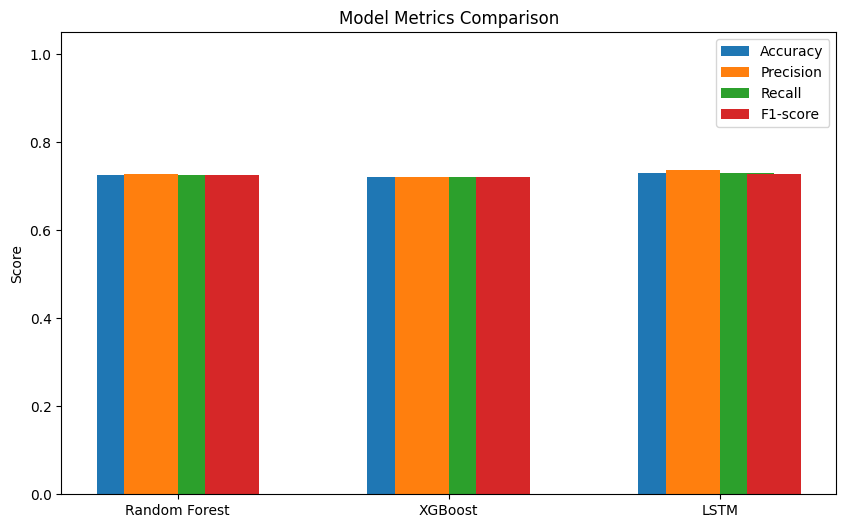

In [101]:
plt.figure(figsize=(10,6))

x = np.arange(len(results["Model"]))
width = 0.2

plt.bar(x - 2*width/2, results["Accuracy"], width, label="Accuracy")
plt.bar(x - width/2, results["Precision"], width, label="Precision")
plt.bar(x + width/2, results["Recall"], width, label="Recall")
plt.bar(x + 2*width/2, results["F1-score"], width, label="F1-score")

plt.title("Model Metrics Comparison")
plt.ylabel("Score")
plt.xticks(x, results["Model"])
plt.ylim(0, 1.05)
plt.legend()

plt.show()

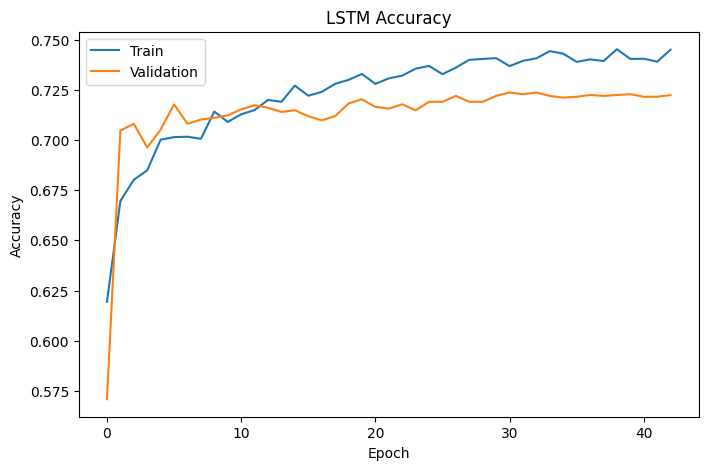

In [102]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])

plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

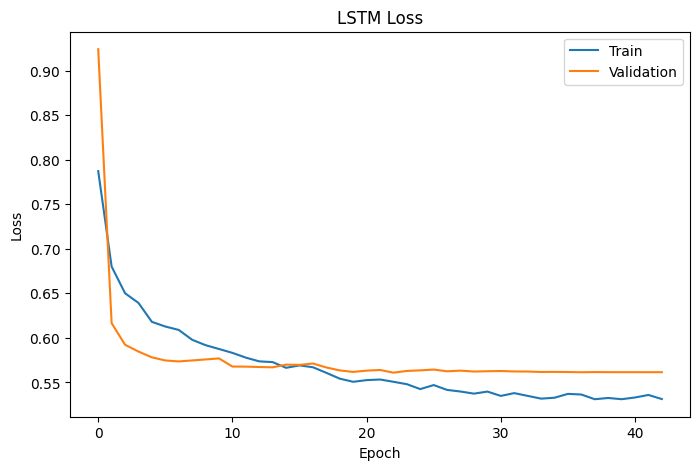

In [103]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])

plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

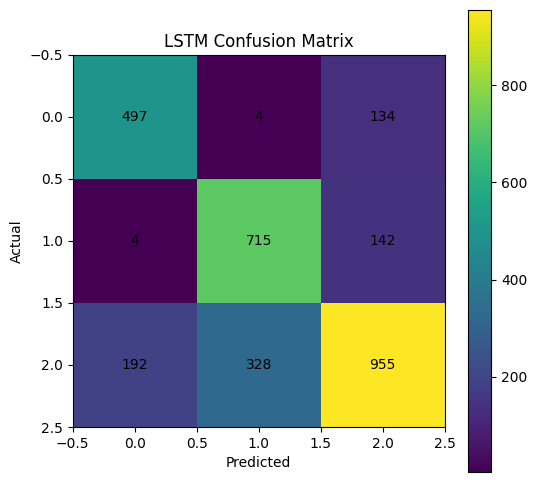

In [104]:
plt.figure(figsize=(6,6))

plt.imshow(lstm_cm)

plt.colorbar()

plt.title("LSTM Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

for i in range(lstm_cm.shape[0]):
    for j in range(lstm_cm.shape[1]):
        plt.text(
            j,
            i,
            str(lstm_cm[i, j]),
            ha="center",
            va="center"
        )

plt.show()

In [105]:
model.save(
    "../models/smartgrid_lstm_model.h5"
)

print("Model Saved")

Model Saved
